# Visualization
## Last-Mile Delivery Operations

Final, presentation-quality visualizations built specifically around
the findings from Business Analysis (Step 9) -- not a random chart
gallery. Every figure here answers one of the 9 business questions or
illustrates one of the two confirmed key drivers (weather, delivery
mode). All figures are saved to `figures/` for reuse in the report
(Step 13) and dashboard (Step 11).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from config.config import PROCESSED_DATA_DIR, FIGURES_DIR
from src.analysis.business_analysis import identify_high_risk_segment
from src.visualization.charts import (
    plot_status_distribution, plot_weather_mode_heatmap,
    plot_mode_reliability_comparison, plot_high_risk_segment_comparison,
    plot_rating_by_status, plot_distance_vs_metric,
    plotly_weather_mode_interactive
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(PROCESSED_DATA_DIR / "delivery_logistics_features.csv")
df.shape

(25000, 24)

## Figure 1 -- Overall Delivery Status (Executive Overview)

The headline KPI chart: sets the baseline every other figure compares
against.

e:\Python projects\last-mile-delivery-analysis\src\visualization\charts.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct.index, y=pct.values, ax=ax, palette="viridis")


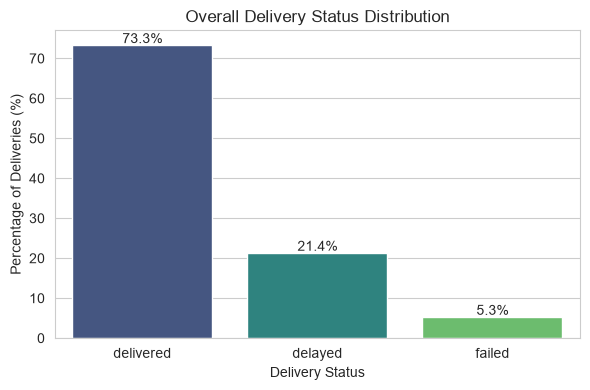

In [3]:
fig = plot_status_distribution(df)
fig.savefig(FIGURES_DIR / "01_overall_delivery_status_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 2 -- Delivery Mode Reliability

Answers Business Question 8. Traffic-light coloring makes the express-
mode problem immediately visible without needing to read numbers.

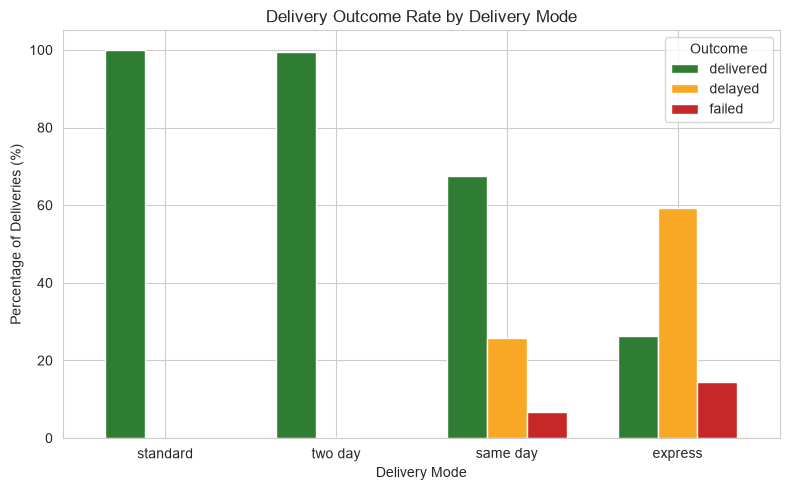

In [4]:
fig = plot_mode_reliability_comparison(df)
fig.savefig(FIGURES_DIR / "fig02_mode_reliability.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 3 -- Weather x Mode Interaction (Root Cause Visual)

The single most important figure in the project: shows failure rate
(%) concentrated in the express row, especially under rainy/stormy
weather. This is the visual evidence for the Business Analysis
root-cause finding.

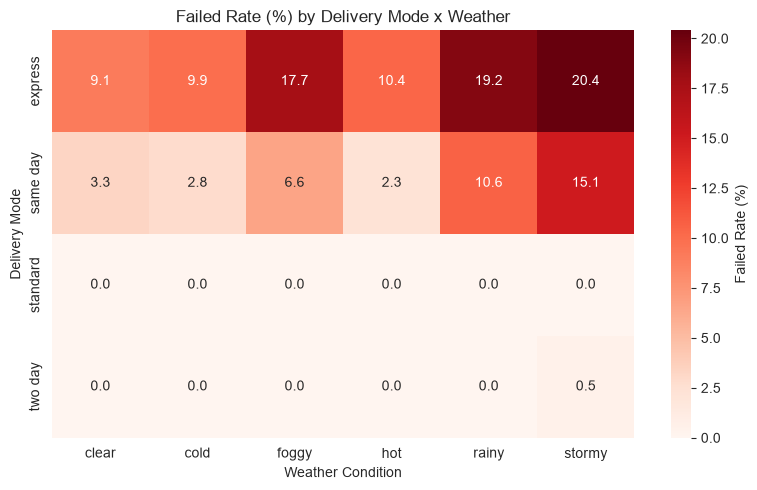

In [5]:
fig = plot_weather_mode_heatmap(df, status_value="failed")
fig.savefig(FIGURES_DIR / "fig03_weather_mode_failed_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 4 -- High-Risk Segment vs. Baseline

Direct visual for management: express + rainy/stormy deliveries
compared to the company-wide baseline. Built to be dropped straight
into a report or slide.

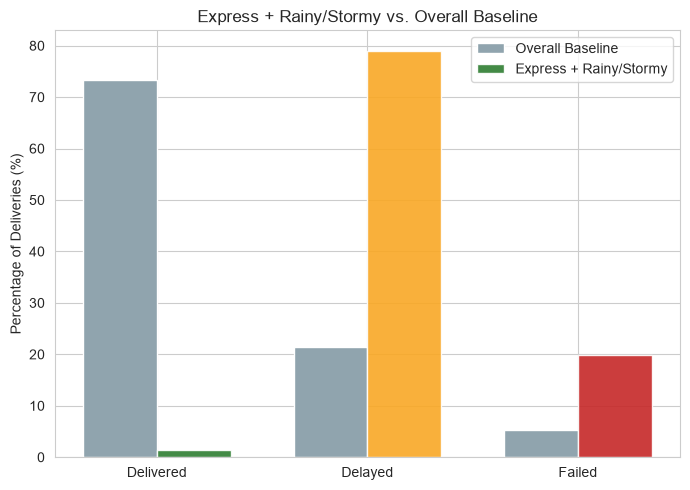

Segment size: 2077 deliveries (8.3% of total volume)


In [6]:
high_risk = identify_high_risk_segment(df, weather_values=["rainy", "stormy"], mode_value="express")

fig = plot_high_risk_segment_comparison(
    segment_dist=high_risk["segment_status_distribution"],
    baseline_dist=high_risk["overall_baseline_distribution"],
    segment_label="Express + Rainy/Stormy"
)
fig.savefig(FIGURES_DIR / "fig04_high_risk_segment.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Segment size: {high_risk['segment_size']} deliveries "
      f"({high_risk['pct_of_total_volume']}% of total volume)")

## Figure 5 -- Customer Rating by Delivery Status

Answers Business Question 7: quantifies the customer-experience cost of
delays and failures found in Section 3.

e:\Python projects\last-mile-delivery-analysis\src\visualization\charts.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=status_col, y=rating_col, order=order, ax=ax, palette="viridis")


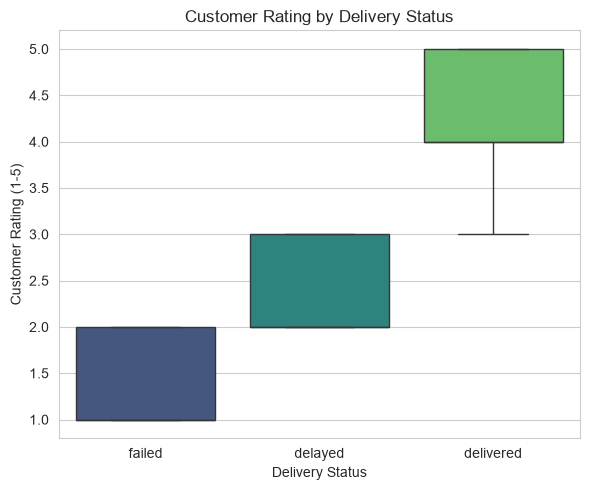

In [8]:
fig = plot_rating_by_status(df)
fig.savefig(FIGURES_DIR / "08_rating_by_status.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 6 -- Distance vs. Delivery Cost

Answers Business Question 6: visual confirmation of the near-perfect
distance-cost relationship (r ≈ 0.99) found in EDA.

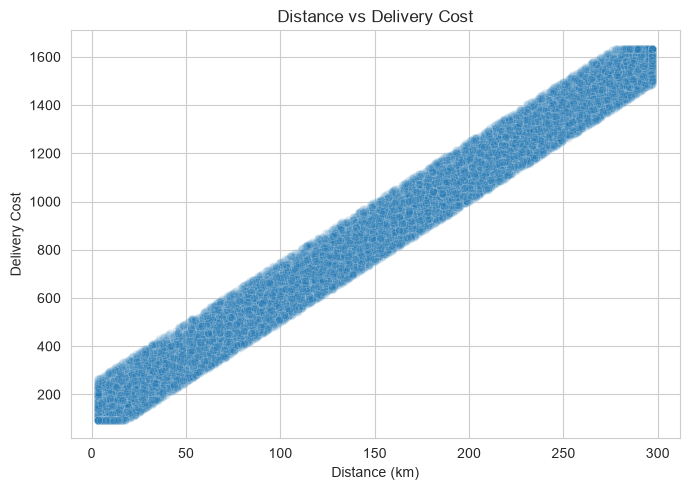

In [9]:
fig = plot_distance_vs_metric(df, "delivery_cost", "Delivery Cost")
fig.savefig(FIGURES_DIR / "07_distance_vs_cost.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 7 -- Interactive Weather x Mode Breakdown (Dashboard-Ready)

A Plotly version of Figure 3 with hover interactivity, built for reuse
directly inside the Streamlit dashboard rather than as a
static report image.

In [10]:
interactive_fig = plotly_weather_mode_interactive(df)
interactive_fig.write_html(FIGURES_DIR / "fig07_weather_mode_interactive.html")
interactive_fig.show()

## Visualization Summary

| Figure | File | Business Question / Finding |
|---|---|---|
| 1 | `fig01_overall_status.png` | Overall on-time/delayed/failed rate |
| 2 | `fig02_mode_reliability.png` | Delivery mode reliability (BQ8) |
| 3 | `fig03_weather_mode_failed_heatmap.png` | Root cause: weather x mode interaction |
| 4 | `fig04_high_risk_segment.png` | High-risk segment vs. baseline |
| 5 | `fig05_rating_by_status.png` | Customer satisfaction driver (BQ7) |
| 6 | `fig06_distance_vs_cost.png` | Distance-cost relationship (BQ6) |
| 7 | `fig07_weather_mode_interactive.html` | Interactive version for dashboard |

All 7 figures are saved in `figures/` and ready for the report and dashboard. Charts intentionally NOT created: a regional
map or partner/vehicle ranking chart -- Business Analysis found these segments are not statistically significant, so a chart
implying meaningful regional/vehicle differences would misrepresent the data.